# Experiment tracking deep dive

In this notebook, we'll go beyond the basics and look at how to manage multiple models and hyperparameters. We'll cover:

1. Training different model types (Random Forest, XGBoost) and logging them all to MLflow.
2. Using **nested runs** to keep hyperparameter searches organized.
3. Comparing results programmatically using `mlflow.search_runs()` instead of just clicking around the UI.

## 1. Setup and imports

In [1]:
import sys, os

REPO_ROOT = os.path.abspath(os.pardir)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost

from src.data_preprocessing import load_data, preprocess, split_data

sns.set_theme(style="whitegrid")
print("MLflow version:", mlflow.__version__)

mlflow.set_tracking_uri(f"sqlite:///{REPO_ROOT}/mlflow.db")

MLflow version: 3.15.2


## 2. Load and prepare data

In [2]:
df = load_data()

# Sample down to reduce memory pressure on the VM (4GB RAM)
df = df.sample(n=25000, random_state=42).reset_index(drop=True)

X, y, scaler, feature_names = preprocess(df)
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (20000, 30), Test: (5000, 30)


## 3. Helper functions

We'll define a few helpers here to handle the evaluation and logging plots. This keeps the training loops cleaner.

In [3]:
def evaluate_model(model, X_test, y_test):
    """Return a dict of classification metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }


def log_confusion_matrix(model, X_test, y_test, title="Confusion Matrix"):
    """Save confusion matrix as PNG and log it as an MLflow artifact."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues")
    ax.set_title(title)
    fig.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.show()


def log_roc_curve(model, X_test, y_test, title="ROC Curve"):
    """Save ROC curve as PNG and log it as an MLflow artifact."""
    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(title)
    fig.tight_layout()
    mlflow.log_figure(fig, "roc_curve.png")
    plt.show()


def log_feature_importance(model, feature_names, title="Feature Importance"):
    """Save feature importance bar chart and log as artifact."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]  # top 15

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(
        [feature_names[i] for i in indices][::-1],
        importances[indices][::-1],
    )
    ax.set_title(title)
    ax.set_xlabel("Importance")
    fig.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

## 4. Random Forest experiments

We'll start by training a few Random Forest models with different depths and tree counts. 

In this section, each model version is logged as its own separate run in the same experiment. This is a simple way to compare a few variants without adding too much complexity.

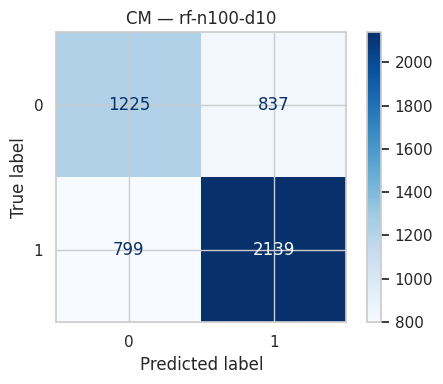

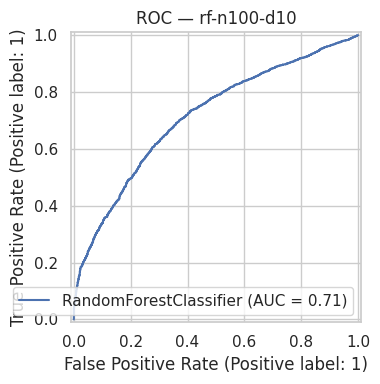

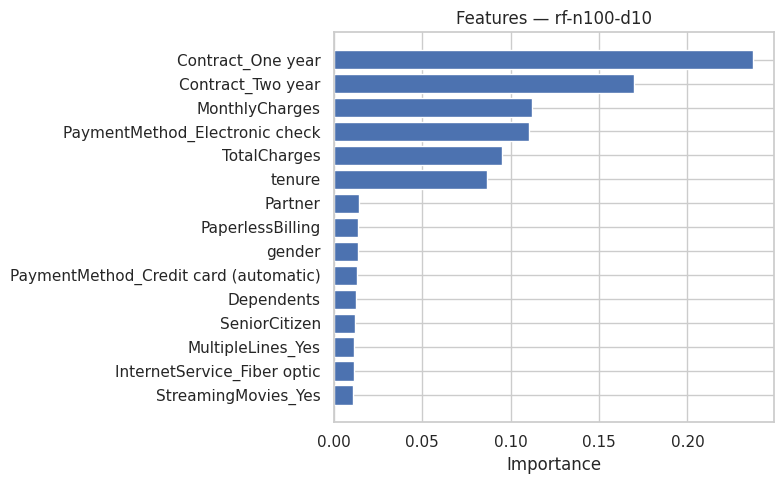

[rf-n100-d10] F1=0.7234  AUC=0.7137


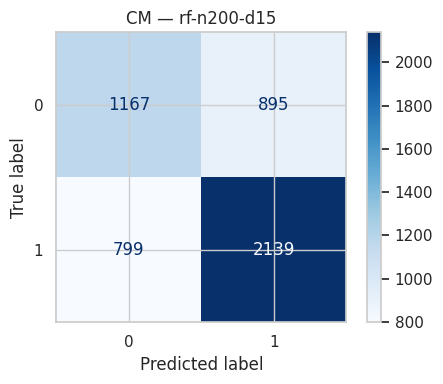

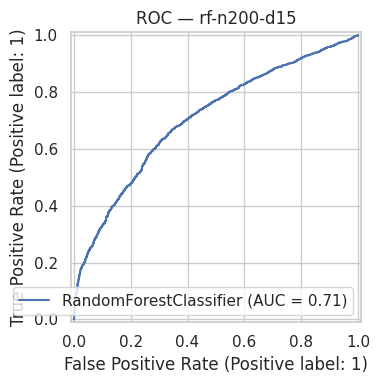

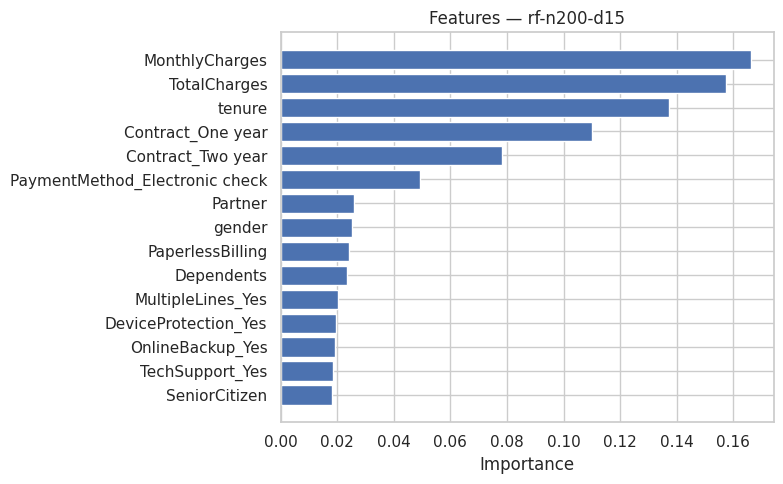

[rf-n200-d15] F1=0.7163  AUC=0.7055


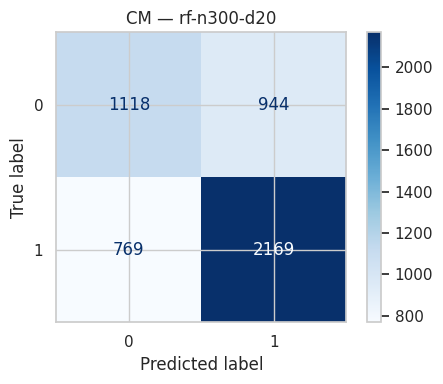

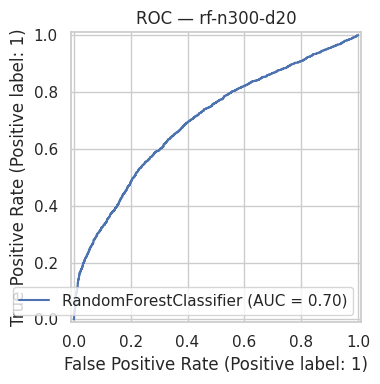

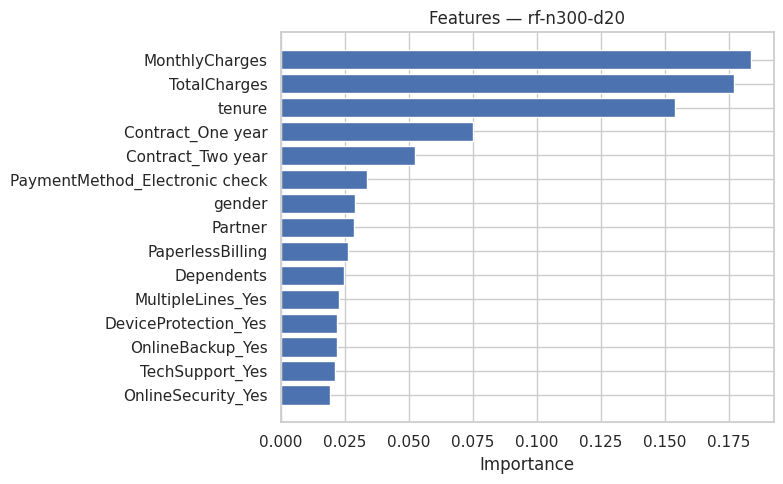

[rf-n300-d20] F1=0.7169  AUC=0.6981


In [4]:
mlflow.set_experiment("telco-churn-experiments")

rf_configs = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 15},
    {"n_estimators": 300, "max_depth": 20},
]

# Create a dataset reference
train_dataset = mlflow.data.from_pandas(X_train, name="training_data")

for config in rf_configs:
    run_name = f"rf-n{config['n_estimators']}-d{config['max_depth']}"

    # Flat approach: each config is its own top-level run
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "RandomForest")
        mlflow.set_tag("run_type", "flat_model_comparison")

        # Log the training dataset for reproducibility
        mlflow.log_input(train_dataset, context="training")

        # Train
        model = RandomForestClassifier(**config, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        # Evaluate
        metrics = evaluate_model(model, X_test, y_test)

        # Log model, params, and metrics
        model_info = mlflow.sklearn.log_model(model, name="rf-model")
        mlflow.log_params(config)
        mlflow.log_metrics(metrics=metrics, model_id=model_info.model_id, dataset=train_dataset)

        # Log artifacts (plots)
        log_confusion_matrix(model, X_test, y_test, f"CM — {run_name}")
        log_roc_curve(model, X_test, y_test, f"ROC — {run_name}")
        log_feature_importance(model, feature_names, f"Features — {run_name}")

        print(f"[{run_name}] F1={metrics['f1_score']:.4f}  AUC={metrics['roc_auc']:.4f}")

## 5. XGBoost experiments

Next, let's try XGBoost. We'll use the same "flat" approach as before, logging each parameter combination as a new run. This makes it easy to compare XGBoost and Random Forest side-by-side in the UI.

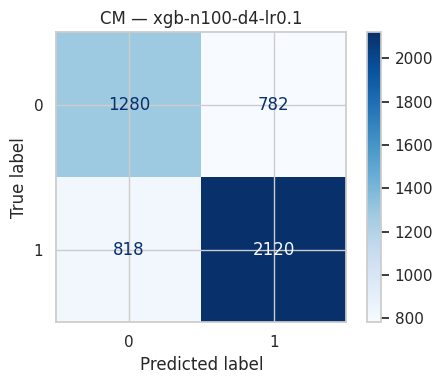

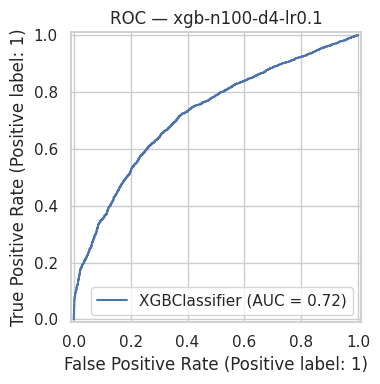

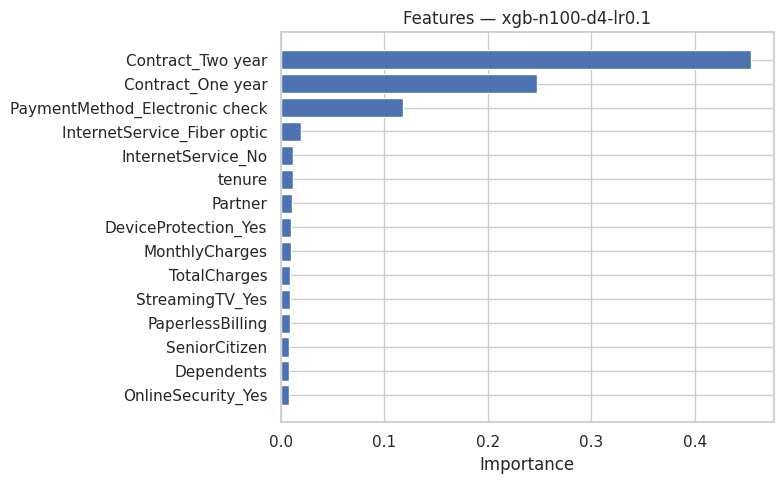

[xgb-n100-d4-lr0.1] F1=0.7260  AUC=0.7219


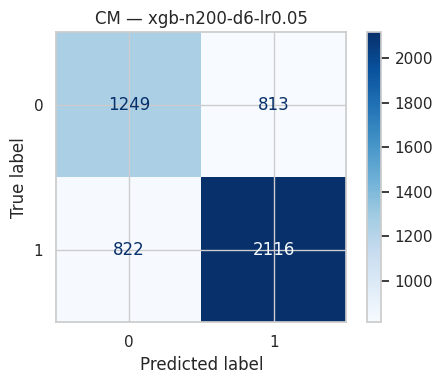

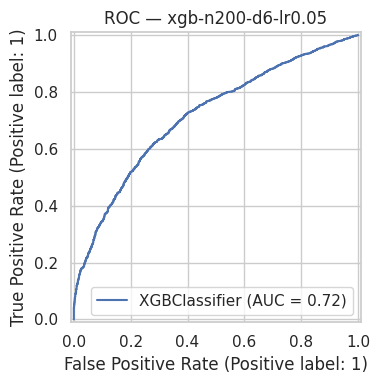

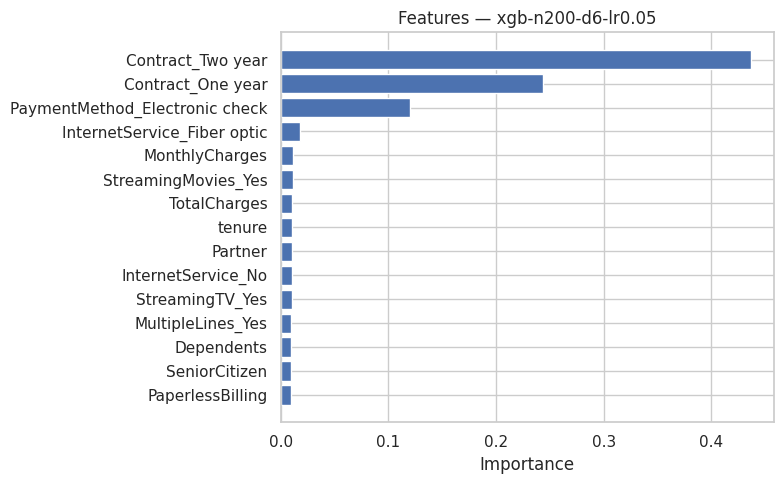

[xgb-n200-d6-lr0.05] F1=0.7213  AUC=0.7164


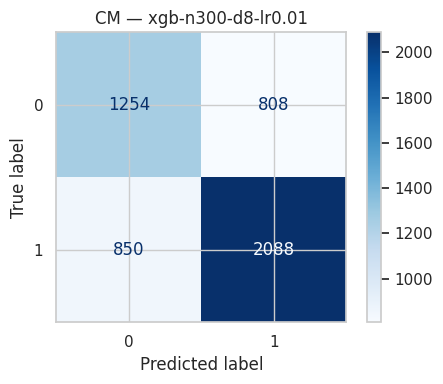

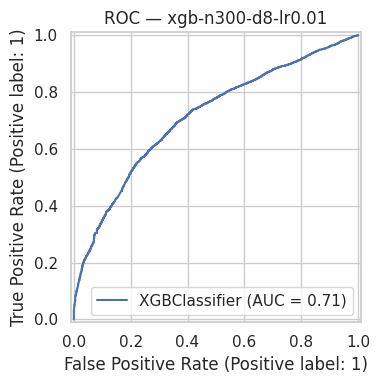

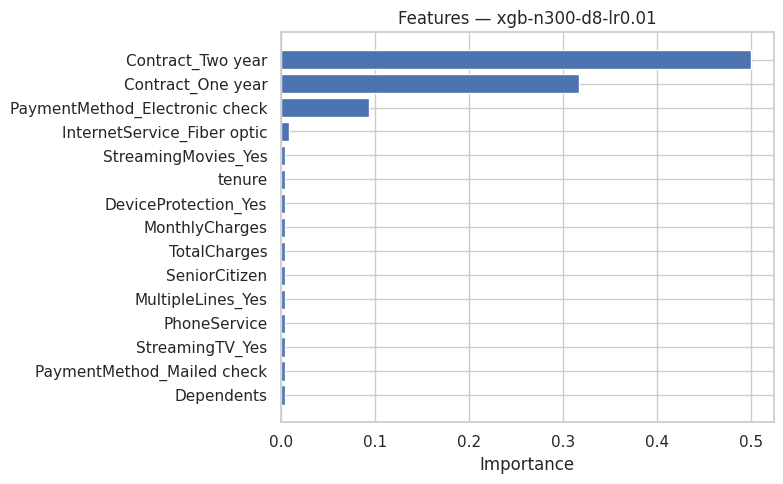

[xgb-n300-d8-lr0.01] F1=0.7158  AUC=0.7130


In [5]:
xgb_configs = [
    {"n_estimators": 100, "max_depth": 4, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 8, "learning_rate": 0.01},
]

for config in xgb_configs:
    run_name = f"xgb-n{config['n_estimators']}-d{config['max_depth']}-lr{config['learning_rate']}"

    # Flat approach: each config is its own top-level run
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "XGBoost")
        mlflow.set_tag("run_type", "flat_model_comparison")

        mlflow.log_input(train_dataset, context="training")

        model = XGBClassifier(
            **config,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42,
        )
        model.fit(X_train, y_train)

        metrics = evaluate_model(model, X_test, y_test)

        model_info = mlflow.xgboost.log_model(model, name="xgb-model")
        mlflow.log_params(config)
        mlflow.log_metrics(metrics=metrics, model_id=model_info.model_id, dataset=train_dataset)

        log_confusion_matrix(model, X_test, y_test, f"CM — {run_name}")
        log_roc_curve(model, X_test, y_test, f"ROC — {run_name}")
        log_feature_importance(model, feature_names, f"Features — {run_name}")

        print(f"[{run_name}] F1={metrics['f1_score']:.4f}  AUC={metrics['roc_auc']:.4f}")

## 6. Nested runs: hyperparameter grid search

Flat runs are fine for a handful of models, but they get messy when you're doing a full grid search. 

We can use **nested runs** to group all those individual trials under one parent run (like `xgb-hyperparam-search`). This keeps the experiment list tidy while still letting you dive into the details of each trial.

In [7]:
from itertools import product

# Hyperparameter grid
n_estimators_grid = [100, 200]
max_depth_grid = [6, 10]
learning_rate_grid = [0.05, 0.1]

with mlflow.start_run(run_name="xgb-hyperparam-search"):
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("run_type", "hyperparameter_search")

    mlflow.log_input(train_dataset, context="training")

    best_f1 = 0
    best_config = None

    for n_est, depth, lr in product(n_estimators_grid, max_depth_grid, learning_rate_grid):
        child_name = f"xgb-n{n_est}-d{depth}-lr{lr}"

        # Each combination gets its own nested (child) run
        with mlflow.start_run(run_name=child_name, nested=True):
            params = {
                "n_estimators": n_est,
                "max_depth": depth,
                "learning_rate": lr,
            }
            mlflow.log_params(params)
            mlflow.set_tag("model_type", "XGBoost")

            model = XGBClassifier(
                **params,
                use_label_encoder=False,
                eval_metric="logloss",
                random_state=42,
            )
            model.fit(X_train, y_train)

            metrics = evaluate_model(model, X_test, y_test)
            model_info = mlflow.xgboost.log_model(model, name="xgb-best-model")
            mlflow.log_metrics(metrics=metrics, model_id=model_info.model_id, dataset=train_dataset)

            print(f"  [{child_name}] F1={metrics['f1_score']:.4f}  AUC={metrics['roc_auc']:.4f}")

            if metrics["f1_score"] > best_f1:
                best_f1 = metrics["f1_score"]
                best_config = params.copy()

    # Log the best result on the parent run
    mlflow.log_metric("best_f1_score", best_f1)
    mlflow.log_params({f"best_{k}": v for k, v in best_config.items()})
    print(f"\nBest config: {best_config} — F1={best_f1:.4f}")

  [xgb-n100-d6-lr0.05] F1=0.7193  AUC=0.7176
  [xgb-n100-d6-lr0.1] F1=0.7154  AUC=0.7170
  [xgb-n100-d10-lr0.05] F1=0.7171  AUC=0.7073
  [xgb-n100-d10-lr0.1] F1=0.7133  AUC=0.6990
  [xgb-n200-d6-lr0.05] F1=0.7213  AUC=0.7164
  [xgb-n200-d6-lr0.1] F1=0.7166  AUC=0.7092
  [xgb-n200-d10-lr0.05] F1=0.7106  AUC=0.6999
  [xgb-n200-d10-lr0.1] F1=0.7059  AUC=0.6871

Best config: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05} — F1=0.7213


## 7. Searching and filtering runs with code

The UI is great, but sometimes it's faster to query your results directly from Python. `mlflow.search_runs()` returns a pandas DataFrame, so you can filter and sort however you want.

> **Note:** You can compare any runs as long as they have the same metrics and parameters logged, even if they have completely different names.

In [8]:
# Get all runs for the telco-churn-experiments experiment
experiment = mlflow.get_experiment_by_name("telco-churn-experiments")
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.f1_score DESC"],
)

# Run names are only labels; comparison is done via params/metrics/tags.
# So yes, runs can have different names and still be compared directly.
cols = [
    "run_id",
    "tags.mlflow.runName",
    "tags.model_type",
    "params.n_estimators",
    "params.max_depth",
    "params.learning_rate",
    "metrics.f1_score",
    "metrics.roc_auc",
    "metrics.accuracy",
]
runs_df[[c for c in cols if c in runs_df.columns]].head(15)

,run_id,tags.mlflow.runName,tags.model_type,params.n_estimators,params.max_depth,params.learning_rate,metrics.f1_score,metrics.roc_auc,metrics.accuracy
0,ef143920b1174580bace14e5c1e7323b,xgb-n100-d4-lr0.1,XGBoost,100,4,0.1,0.726027,0.721890,0.68000
1,bd92eead07ea4d0e9b18dd939b0d413f,rf-n100-d10,RandomForest,100,10,None,0.724437,0.727090,0.68025
2,4d16e3d4bb1f4573a30ed81ef1f24d49,rf-n100-d10,RandomForest,100,10,None,0.724437,0.727090,0.68025
3,49686e1317c94898a9c865504f35bd22,rf-n100-d10,RandomForest,100,10,None,0.724437,0.727090,0.68025
4,f55d04f14eba4e8faa68dc4d9a247599,rf-n100-d10,RandomForest,100,10,None,0.724437,0.727090,0.68025
5,481ca89a2042441080b379f8612d69ae,rf-n100-d10,RandomForest,100,10,None,0.724437,0.727090,0.68025
6,c4c32c60822b44a3966ba4a6c3b4eb4e,rf-n100-d10,RandomForest,100,10,None,0.723368,0.713743,0.67280
7,c4965c5ea13d4b10815de6efa8fcb0d2,xgb-n200-d6-lr0.05,XGBoost,200,6,0.05,0.721323,0.716409,0.67300
8,c8f8c9026bff4f6d84033d7743cbb22c,xgb-n200-d6-lr0.05,XGBoost,200,6,0.05,0.721323,0.716409,0.67300
9,af692c91c05742cbaf8755236fb1ec8e,xgb-n200-d6-lr0.05,XGBoost,200,6,0.05,0.721323,0.716409,0.67300


In [9]:
# Filter: only Random Forest runs with F1 > 0.5
rf_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.model_type = 'RandomForest' AND metrics.f1_score > 0.5",
    order_by=["metrics.f1_score DESC"],
)
print(f"Random Forest runs with F1 > 0.5: {len(rf_runs)}")
rf_runs[[c for c in cols if c in rf_runs.columns]].head()

Random Forest runs with F1 > 0.5: 13


,run_id,tags.mlflow.runName,tags.model_type,params.n_estimators,params.max_depth,metrics.f1_score,metrics.roc_auc,metrics.accuracy
0,bd92eead07ea4d0e9b18dd939b0d413f,rf-n100-d10,RandomForest,100,10,0.724437,0.72709,0.68025
1,4d16e3d4bb1f4573a30ed81ef1f24d49,rf-n100-d10,RandomForest,100,10,0.724437,0.72709,0.68025
2,49686e1317c94898a9c865504f35bd22,rf-n100-d10,RandomForest,100,10,0.724437,0.72709,0.68025
3,f55d04f14eba4e8faa68dc4d9a247599,rf-n100-d10,RandomForest,100,10,0.724437,0.72709,0.68025
4,481ca89a2042441080b379f8612d69ae,rf-n100-d10,RandomForest,100,10,0.724437,0.72709,0.68025


## 8. Visualizing run comparisons

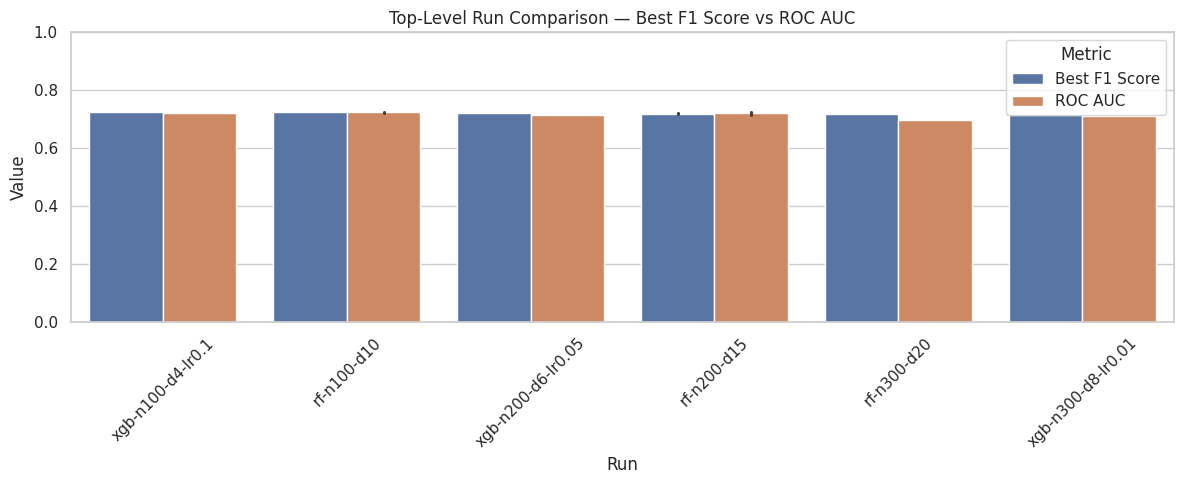

In [10]:
# Compare top-level runs only (exclude nested child runs).
# This includes flat runs from sections 4/5 and parent runs such as xgb-hyperparam-search.
all_runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.best_f1_score DESC", "metrics.f1_score DESC"],
)

top_level_mask = all_runs["tags.mlflow.parentRunId"].isna() | (all_runs["tags.mlflow.parentRunId"] == "")
top_level_runs = all_runs[top_level_mask].copy()

# Use best_f1_score when present (e.g., tuning parent run), otherwise f1_score
# from regular flat runs.
top_level_runs["display_f1"] = top_level_runs["metrics.best_f1_score"].fillna(
    top_level_runs["metrics.f1_score"]
)
top_level_runs["display_auc"] = top_level_runs["metrics.roc_auc"]

plot_df = top_level_runs[["tags.mlflow.runName", "display_f1", "display_auc"]].dropna()
plot_df = plot_df.rename(columns={
    "tags.mlflow.runName": "Run",
    "display_f1": "Best F1 Score",
    "display_auc": "ROC AUC",
})

plot_df_melted = plot_df.melt(id_vars="Run", var_name="Metric", value_name="Value")

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=plot_df_melted, x="Run", y="Value", hue="Metric", ax=ax)
ax.set_title("Top-Level Run Comparison — Best F1 Score vs ROC AUC")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Diving into the MLflow UI

Fire up the UI (`mlflow ui --port 5000`) and take a look at:

- **The difference between flat and nested runs**: Notice how the grid search runs are grouped.
- **Comparing runs**: Select a few and click "Compare" to see them side-by-side.
- **Parallel coordinates**: This is a great way to see how hyperparameters actually affect your metrics.
- **Artifacts**: Check out the confusion matrices and ROC curves we logged.